Análise Exploratória de Dados - Datathon Passos Mágicos
Fase 5 - POSTECH FIAP

Análise do dataset PEDE (2022-2024) da Associação Passos Mágicos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
palette = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6']

DATA_PATH = r'../BASE DE DADOS PEDE 2024 - DATATHON.xlsx'

1. Carregamento e Limpeza dos Dados

In [2]:
df22 = pd.read_excel(DATA_PATH, sheet_name='PEDE2022')
df23 = pd.read_excel(DATA_PATH, sheet_name='PEDE2023')
df24 = pd.read_excel(DATA_PATH, sheet_name='PEDE2024')
print(f"2022: {df22.shape} | 2023: {df23.shape} | 2024: {df24.shape}")

2022: (860, 42) | 2023: (1014, 48) | 2024: (1156, 50)


In [3]:
# Padronizar colunas do 2022 para ficar compatível com 2023/2024
rename_22 = {
    'Fase': 'Fase_num', 'Turma': 'Turma', 'Nome': 'Nome',
    'Ano nasc': 'Ano_nasc', 'Idade 22': 'Idade', 'Gênero': 'Genero',
    'Ano ingresso': 'Ano_ingresso', 'Instituição de ensino': 'Instituicao',
    'Pedra 22': 'Pedra', 'INDE 22': 'INDE',
    'Cg': 'Cg', 'Cf': 'Cf', 'Ct': 'Ct', 'Nº Av': 'Num_Av',
    'IAA': 'IAA', 'IEG': 'IEG', 'IPS': 'IPS', 'IDA': 'IDA',
    'Matem': 'Mat', 'Portug': 'Por', 'Inglês': 'Ing',
    'Indicado': 'Indicado', 'Atingiu PV': 'Atingiu_PV',
    'IPV': 'IPV', 'IAN': 'IAN', 'Fase ideal': 'Fase_Ideal',
    'Defas': 'Defasagem', 'Destaque IEG': 'Dest_IEG',
    'Destaque IDA': 'Dest_IDA', 'Destaque IPV': 'Dest_IPV',
    'Rec Psicologia': 'Rec_Psico', 'Pedra 20': 'Pedra_20', 'Pedra 21': 'Pedra_21'
}
df22r = df22.rename(columns=rename_22)
df22r['Ano'] = 2022
df22r['IPP'] = np.nan

# Mapear Fase numérica para texto
fase_map = {0: 'ALFA', 1: 'FASE 1', 2: 'FASE 2', 3: 'FASE 3',
            4: 'FASE 4', 5: 'FASE 5', 6: 'FASE 6', 7: 'FASE 7'}
df22r['Fase'] = df22r['Fase_num'].map(fase_map)

# Padronizar gênero
df22r['Genero'] = df22r['Genero'].map({'Menina': 'Feminino', 'Menino': 'Masculino'})

In [4]:
rename_23 = {
    'Fase': 'Fase', 'Turma': 'Turma', 'Nome Anonimizado': 'Nome',
    'Idade': 'Idade', 'Gênero': 'Genero',
    'Ano ingresso': 'Ano_ingresso', 'Instituição de ensino': 'Instituicao',
    'Pedra 2023': 'Pedra', 'INDE 2023': 'INDE',
    'Cg': 'Cg', 'Cf': 'Cf', 'Ct': 'Ct', 'Nº Av': 'Num_Av',
    'IAA': 'IAA', 'IEG': 'IEG', 'IPS': 'IPS', 'IPP': 'IPP',
    'IDA': 'IDA', 'Mat': 'Mat', 'Por': 'Por', 'Ing': 'Ing',
    'Indicado': 'Indicado', 'Atingiu PV': 'Atingiu_PV',
    'IPV': 'IPV', 'IAN': 'IAN', 'Fase Ideal': 'Fase_Ideal',
    'Defasagem': 'Defasagem', 'Destaque IEG': 'Dest_IEG',
    'Destaque IDA': 'Dest_IDA', 'Destaque IPV': 'Dest_IPV',
    'Rec Psicologia': 'Rec_Psico', 'Pedra 20': 'Pedra_20',
    'Pedra 21': 'Pedra_21', 'Pedra 22': 'Pedra_22'
}
df23r = df23.rename(columns=rename_23)
df23r['Ano'] = 2023
df23r['Idade'] = pd.to_numeric(df23r['Idade'], errors='coerce')

In [5]:
rename_24 = {
    'Fase': 'Fase', 'Turma': 'Turma', 'Nome Anonimizado': 'Nome',
    'Idade': 'Idade', 'Gênero': 'Genero',
    'Ano ingresso': 'Ano_ingresso', 'Instituição de ensino': 'Instituicao',
    'Pedra 2024': 'Pedra', 'INDE 2024': 'INDE',
    'Cg': 'Cg', 'Cf': 'Cf', 'Ct': 'Ct', 'Nº Av': 'Num_Av',
    'IAA': 'IAA', 'IEG': 'IEG', 'IPS': 'IPS', 'IPP': 'IPP',
    'IDA': 'IDA', 'Mat': 'Mat', 'Por': 'Por', 'Ing': 'Ing',
    'Indicado': 'Indicado', 'Atingiu PV': 'Atingiu_PV',
    'IPV': 'IPV', 'IAN': 'IAN', 'Fase Ideal': 'Fase_Ideal',
    'Defasagem': 'Defasagem', 'Destaque IEG': 'Dest_IEG',
    'Destaque IDA': 'Dest_IDA', 'Destaque IPV': 'Dest_IPV',
    'Rec Psicologia': 'Rec_Psico', 'Pedra 20': 'Pedra_20',
    'Pedra 21': 'Pedra_21', 'Pedra 22': 'Pedra_22',
    'Pedra 23': 'Pedra_23'
}
df24r = df24.rename(columns=rename_24)
df24r['Ano'] = 2024
df24r['INDE'] = pd.to_numeric(df24r['INDE'], errors='coerce')

In [6]:
# Colunas comuns para consolidação
cols = ['RA', 'Ano', 'Fase', 'Genero', 'Idade', 'Ano_ingresso', 'Instituicao',
        'Pedra', 'INDE', 'IAA', 'IEG', 'IPS', 'IPP', 'IDA', 'Mat', 'Por', 'Ing',
        'IPV', 'IAN', 'Defasagem', 'Fase_Ideal', 'Indicado', 'Atingiu_PV', 'Num_Av']

for c in cols:
    for df in [df22r, df23r, df24r]:
        if c not in df.columns:
            df[c] = np.nan

df = pd.concat([df22r[cols], df23r[cols], df24r[cols]], ignore_index=True)

# Padronizar Pedra
df['Pedra'] = df['Pedra'].replace({'Agata': 'Ágata'})
# Remover linhas sem INDE
df = df.dropna(subset=['INDE'])
# Converter tipos
for c in ['IAA','IEG','IPS','IPP','IDA','Mat','Por','Ing','IPV','IAN']:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df['Defasagem'] = pd.to_numeric(df['Defasagem'], errors='coerce')

print(f"Dataset consolidado: {df.shape}")
print(f"\nDistribuição por ano:\n{df['Ano'].value_counts().sort_index()}")
print(f"\nNulos por coluna:\n{df.isnull().sum()}")

Dataset consolidado: (2845, 24)

Distribuição por ano:
Ano
2022     860
2023     931
2024    1054
Name: count, dtype: int64

Nulos por coluna:
RA                 0
Ano                0
Fase               0
Genero             0
Idade            367
Ano_ingresso       0
Instituicao        1
Pedra              0
INDE               0
IAA                0
IEG                0
IPS                0
IPP              860
IDA                0
Mat                6
Por                7
Ing             1761
IPV                0
IAN                0
Defasagem          0
Fase_Ideal         0
Indicado        1985
Atingiu_PV      1985
Num_Av             0
dtype: int64


In [7]:
# Salvar dataset limpo
df.to_csv(r'../data/processed/dataset_consolidado.csv', index=False)
print("Dataset salvo em data/processed/dataset_consolidado.csv")

Dataset salvo em data/processed/dataset_consolidado.csv


2. Pergunta 1 - Adequação do Nível (IAN)
*Qual é o perfil geral de defasagem dos alunos e como evolui ao longo dos anos?*

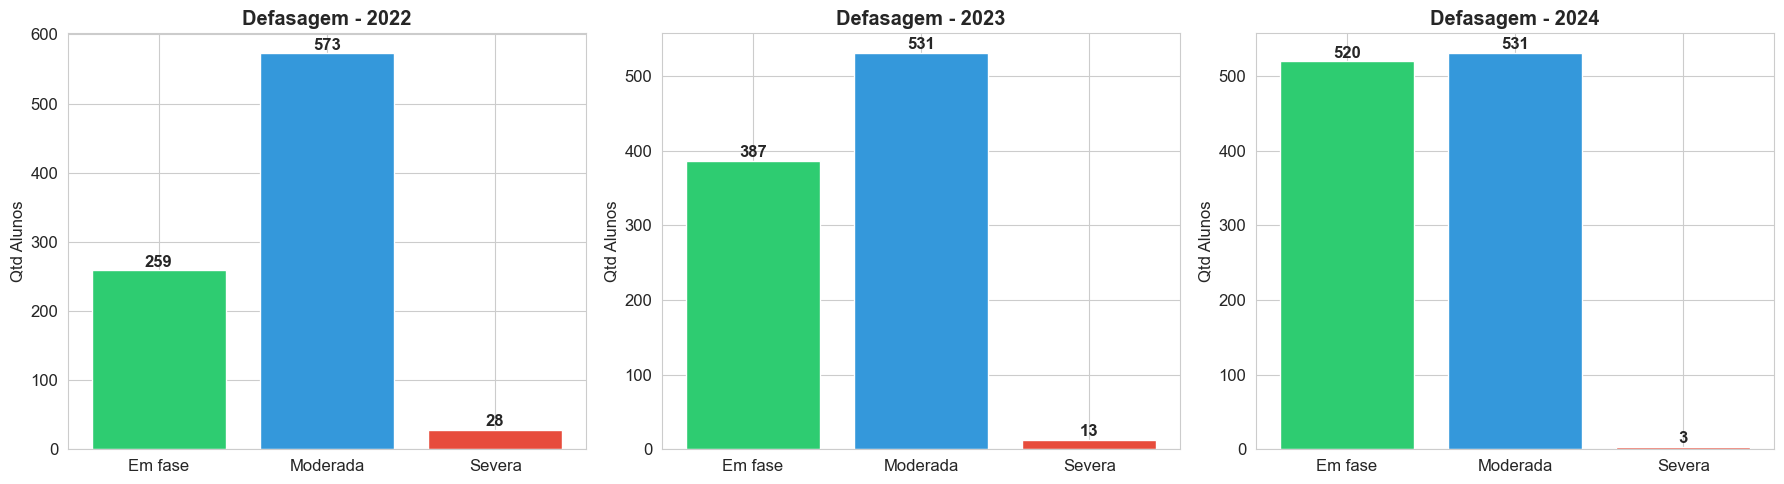

In [8]:
def categorizar_defasagem(d):
    if d >= 0: return 'Em fase'
    elif d < 0 and d >= -2: return 'Moderada'
    else: return 'Severa'

df['Cat_Defasagem'] = df['Defasagem'].apply(categorizar_defasagem)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribuição por ano
for i, ano in enumerate([2022, 2023, 2024]):
    sub = df[df['Ano'] == ano]['Cat_Defasagem'].value_counts()
    sub = sub.reindex(['Em fase', 'Moderada', 'Severa'], fill_value=0)
    axes[i].bar(sub.index, sub.values, color=palette[:4])
    axes[i].set_title(f'Defasagem - {ano}', fontweight='bold')
    axes[i].set_ylabel('Qtd Alunos')
    for j, v in enumerate(sub.values):
        axes[i].text(j, v+5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/q1_defasagem_dist.png', dpi=150, bbox_inches='tight')
plt.show()

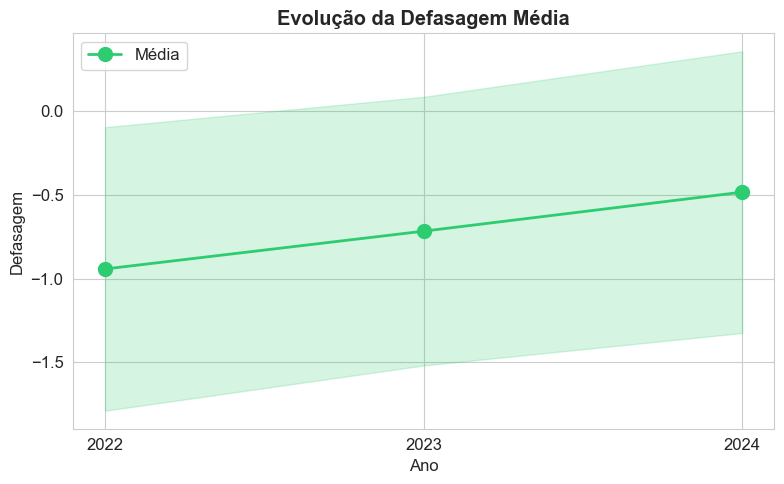

Insight Q1: A defasagem média evolui de -0.94 (2022) para -0.48 (2024).
Percentual adequado por ano:
  2022: 30.1%
  2023: 41.6%
  2024: 49.3%


In [9]:
# Evolução da defasagem média
defas_ano = df.groupby('Ano')['Defasagem'].agg(['mean', 'median', 'std']).reset_index()
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(defas_ano['Ano'], defas_ano['mean'], 'o-', color=palette[0], linewidth=2, markersize=10, label='Média')
ax.fill_between(defas_ano['Ano'], defas_ano['mean']-defas_ano['std'], defas_ano['mean']+defas_ano['std'], alpha=0.2, color=palette[0])
ax.set_xlabel('Ano'); ax.set_ylabel('Defasagem'); ax.set_title('Evolução da Defasagem Média', fontweight='bold')
ax.legend(); ax.set_xticks([2022, 2023, 2024])
plt.tight_layout(); plt.savefig('../data/processed/q1_defasagem_evolucao.png', dpi=150, bbox_inches='tight'); plt.show()

print(f"Insight Q1: A defasagem média evolui de {defas_ano.iloc[0]['mean']:.2f} (2022) para {defas_ano.iloc[-1]['mean']:.2f} (2024).")
print(f"Percentual adequado por ano:")
for ano in [2022, 2023, 2024]:
    sub = df[df['Ano'] == ano]
    pct = (sub['Defasagem'] >= 0).sum() / len(sub) * 100
    print(f"  {ano}: {pct:.1f}%")

**Insight — Perfil Geral de Defasagem e sua Evolução (2022–2024)**

Os dados revelam uma **tendência positiva e consistente** na redução da defasagem escolar dos alunos atendidos pela Passos Mágicos ao longo do período analisado:

- **A defasagem média** melhorou significativamente, saindo de **-0,94 em 2022** para **-0,48 em 2024**, o que representa uma redução de aproximadamente **49%** no indicador negativo em apenas dois anos.

- O **percentual de alunos em fase adequada** (defasagem ≥ 0) cresceu de forma expressiva: de **30,1% em 2022** para **41,6% em 2023**, atingindo **49,3% em 2024**. Isso significa que, em 2024, quase **metade dos alunos** já se encontrava no nível escolar esperado para sua idade — um ganho de quase **20 pontos percentuais** em relação a 2022.

- Em contrapartida, a proporção de alunos com defasagem moderada e severa vem diminuindo ano a ano, indicando que as intervenções pedagógicas e o acompanhamento da associação estão surtindo efeito concreto na adequação do nível dos estudantes.

**Conclusão:** A Passos Mágicos demonstra eficácia crescente na redução da defasagem escolar. Contudo, mesmo em 2024, ainda há cerca de **50% dos alunos** fora da fase ideal, o que reforça a necessidade de manutenção e intensificação dos programas de apoio, com foco especial nos alunos com defasagem severa, que são os mais vulneráveis ao abandono ou à estagnação acadêmica.

3. Pergunta 2 - Desempenho Acadêmico (IDA)
*O desempenho acadêmico médio está melhorando, estagnado ou caindo?*

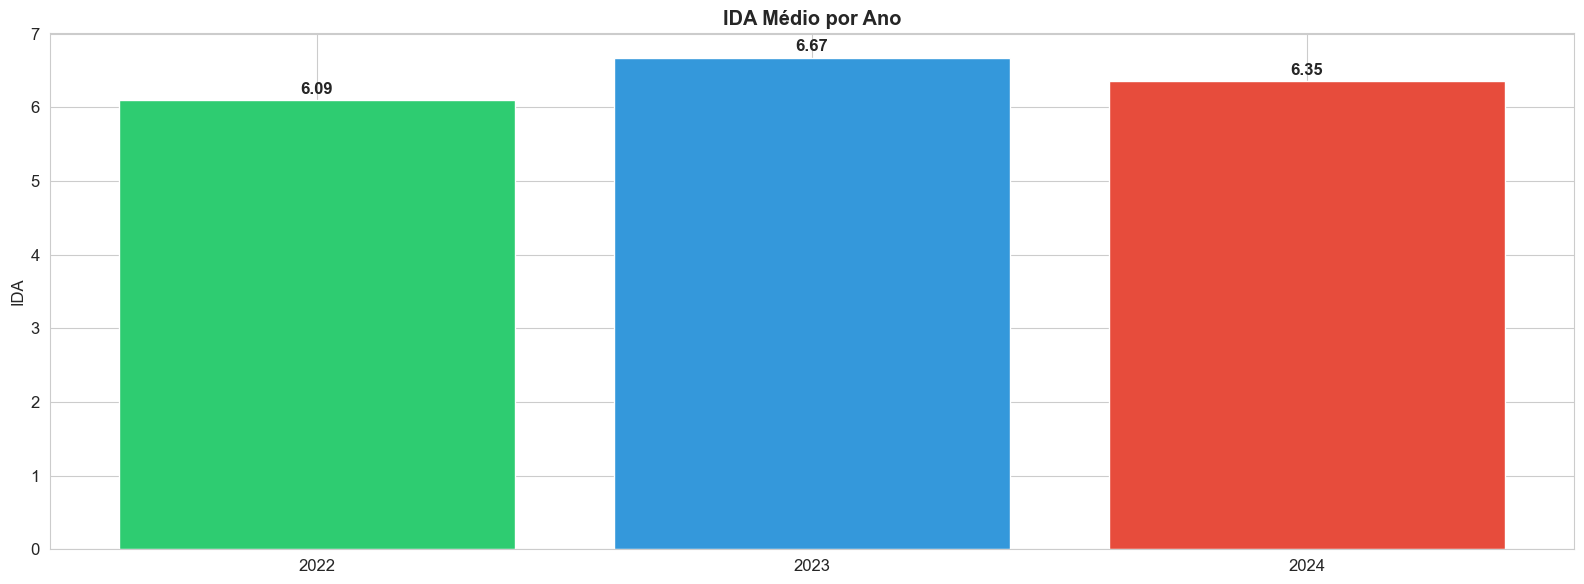

In [10]:
fig, ax = plt.subplots(figsize=(16, 6))

# IDA por ano
ida_ano = df.groupby('Ano')['IDA'].mean()
bars = ax.bar(ida_ano.index.astype(str), ida_ano.values, color=palette[:3])
ax.set_title('IDA Médio por Ano', fontweight='bold')
ax.set_ylabel('IDA')
# Adicionar valores sobre cada barra
for bar in bars:
    altura = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, altura + 0.05,
            f'{altura:.2f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/q2_1.png', dpi=150, bbox_inches='tight')
plt.show()

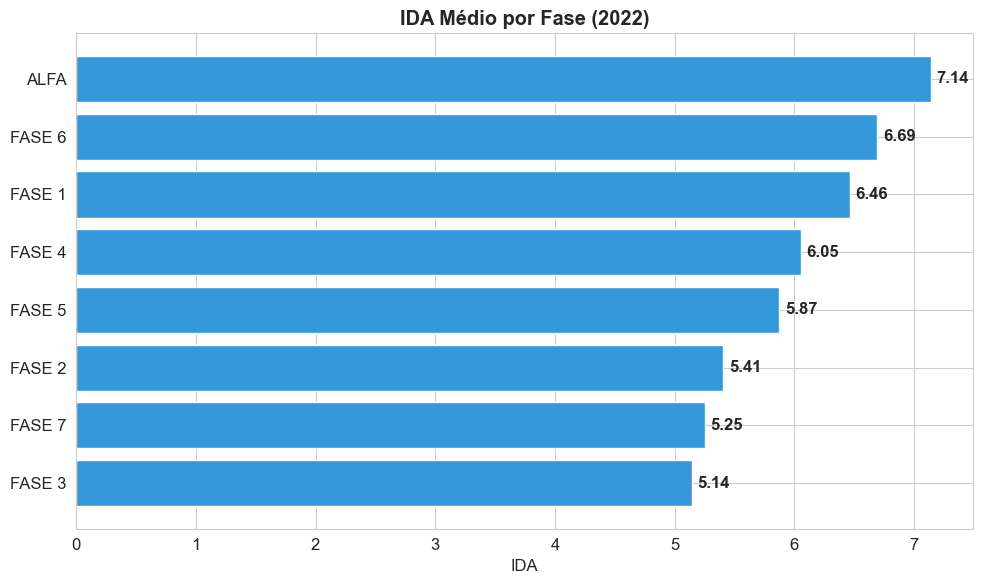

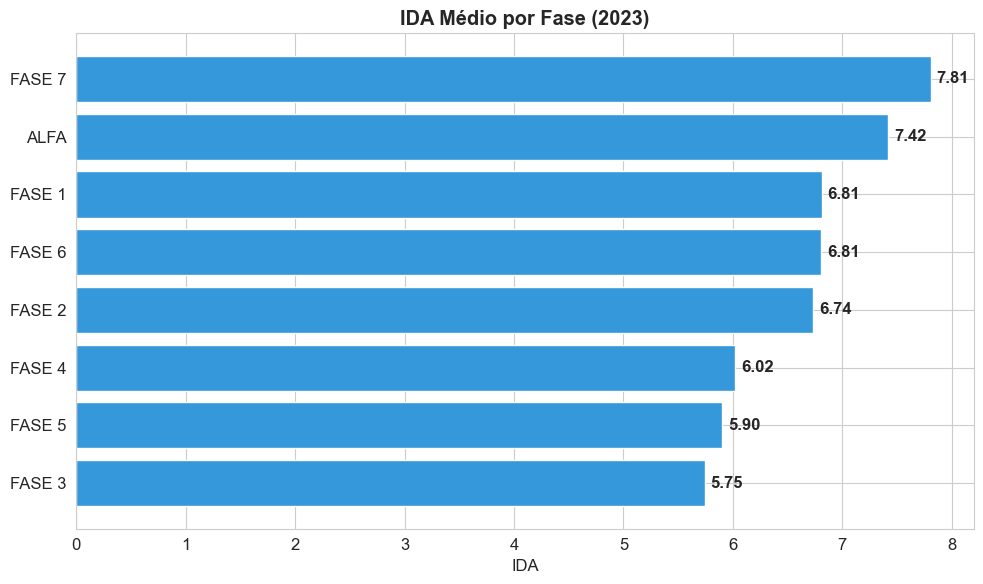

In [11]:
for ano in [2022, 2023]:
    ida_fase = df[df['Ano'] == ano].groupby('Fase')['IDA'].mean().sort_values()
    
    fig, ax = plt.subplots(figsize=(10, 6))  # nova figure a cada iteração
    bars = ax.barh(ida_fase.index, ida_fase.values, color=palette[1])
    ax.set_title(f'IDA Médio por Fase ({ano})', fontweight='bold')
    ax.set_xlabel('IDA')
    # Adicionar valores nas barras
    for bar, val in zip(bars, ida_fase.values):
        ax.text(val + 0.05, bar.get_y() + bar.get_height()/2, 
                f'{val:.2f}', va='center', fontweight='bold')
    plt.tight_layout()
    plt.savefig('../data/processed/q2_'+str(ano)+'.png', dpi=150, bbox_inches='tight')
    plt.show()  # exibe e "fecha" a figure atual


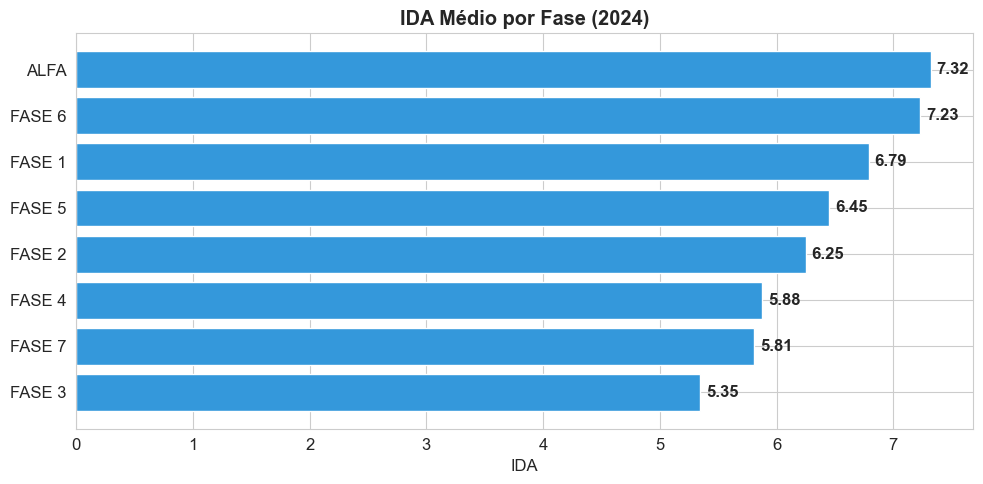

In [12]:
# Extrair o número da fase do início do nome (ex: "1M" → "1", "ALFA" → "ALFA")
import re

def extrair_fase(turma):
    if turma.upper().startswith('ALFA'):
        return 'ALFA'
    match = re.match(r'^(\d+)', str(turma))
    if match:
        return f'FASE {match.group(1)}'
    return turma

sub = df[df['Ano'] == 2024].copy()
sub['Fase_grupo'] = sub['Fase'].apply(extrair_fase)

ida_fase = sub.groupby('Fase_grupo')['IDA'].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(ida_fase.index, ida_fase.values, color=palette[1])
ax.set_title('IDA Médio por Fase (2024)', fontweight='bold')
ax.set_xlabel('IDA')

# Adicionar valores nas barras
for bar, val in zip(bars, ida_fase.values):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2, 
            f'{val:.2f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/q2_2024.png', dpi=150, bbox_inches='tight');
plt.show()


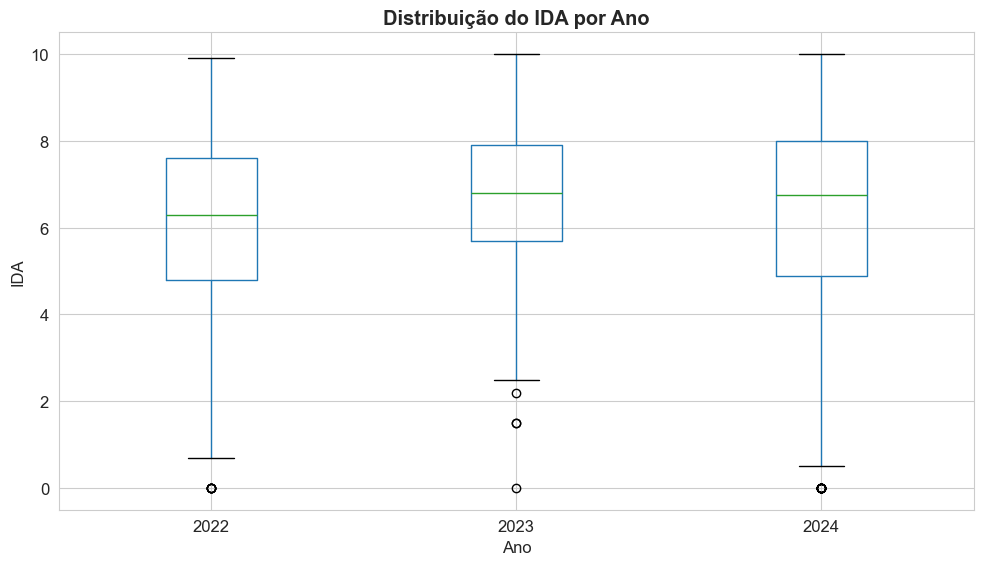

In [13]:

# Box plot evolução
fig, ax = plt.subplots(figsize=(10, 6))
df.boxplot(column='IDA', by='Ano', ax=ax)
ax.set_title('Distribuição do IDA por Ano', fontweight='bold')
ax.set_xlabel('Ano'); ax.set_ylabel('IDA')
plt.suptitle(''); plt.tight_layout(); plt.savefig('../data/processed/q2_boxplot.png', dpi=150, bbox_inches='tight'); plt.show()

**Insight — Pergunta 2: Desempenho Acadêmico (IDA) — Evolução 2022–2024**

**Pergunta:** *O desempenho acadêmico médio está melhorando, estagnado ou caindo?*

#### Visão Geral
O IDA médio apresentou uma trajetória **não-linear**: subiu de **6,09 (2022)** para **6,67 (2023)** (+9,5%), mas recuou para **6,35 (2024)** (-4,8%). Ainda assim, o patamar de 2024 permanece **4,3% acima de 2022**, indicando que houve melhoria no período como um todo, embora com sinais de desaceleração.

#### Análise por Fase

| Fase | 2022 | 2023 | 2024 | Tendência |
|------|------|------|------|-----------|
| ALFA | 7,14 | 7,42 | 7,32 | ✅ Estável/alto |
| FASE 1 | 6,46 | 6,81 | 6,79 | ✅ Estável/alto |
| FASE 2 | 5,41 | 6,74 | 6,25 | ⚠️ Subiu em 2023, recuou em 2024 |
| **FASE 3** | **5,14** | **5,75** | **5,35** | 🔴 **Menor IDA em todos os anos** |
| FASE 4 | 6,05 | 6,02 | 5,88 | 🔴 Queda lenta e consistente |
| FASE 5 | 5,87 | 5,90 | 6,45 | ✅ Crescimento em 2024 |
| FASE 6 | 6,69 | 6,81 | 7,23 | ✅ Crescimento consistente |
| FASE 7 | 5,25 | **7,81** | 5,81 | ⚠️ Pico atípico em 2023, retorno à base |

**Destaques:**

- **FASE 3 é o ponto crítico**: tem o **menor IDA** em todos os três anos (5,14 → 5,75 → 5,35), sem conseguir sustentar os ganhos de 2023. Isso sugere que essa fase é um gargalo acadêmico persistente que demanda intervenção prioritária.

- **FASE 7 em 2023** apresentou um pico atípico (7,81), possivelmente influenciado por uma turma excepcionalmente forte ou por tamanho amostral reduzido. Em 2024, retornou a 5,81, próximo ao patamar de 2022.

- **ALFA e FASE 6** mantêm os **melhores desempenhos** de forma consistente, com IDAs acima de 7,0.

- **FASE 4** mostra uma **queda lenta mas contínua** (6,05 → 6,02 → 5,88), indicando necessidade de atenção preventiva antes que se torne um segundo ponto crítico.

#### Distribuição (Box Plot)
A mediana do IDA subiu de ~6,3 (2022) para ~6,8 (2023/2024), sugerindo que o **aluno típico melhorou**. Porém, a presença de outliers próximos a zero em todos os anos evidencia que um grupo de alunos permanece em situação de extrema dificuldade acadêmica.

**Conclusão:** O desempenho acadêmico geral está **melhorando gradualmente**, mas a FASE 3 é um gargalo crônico que precisa de intervenções pedagógicas diferenciadas. A queda do IDA médio em 2024 em relação a 2023 merece monitoramento para verificar se é uma oscilação pontual ou o início de uma tendência de reversão.

4. Pergunta 3 - Engajamento (IEG) vs Desempenho (IDA) e Ponto de Virada (IPV)
*O engajamento tem relação direta com desempenho e ponto de virada?*

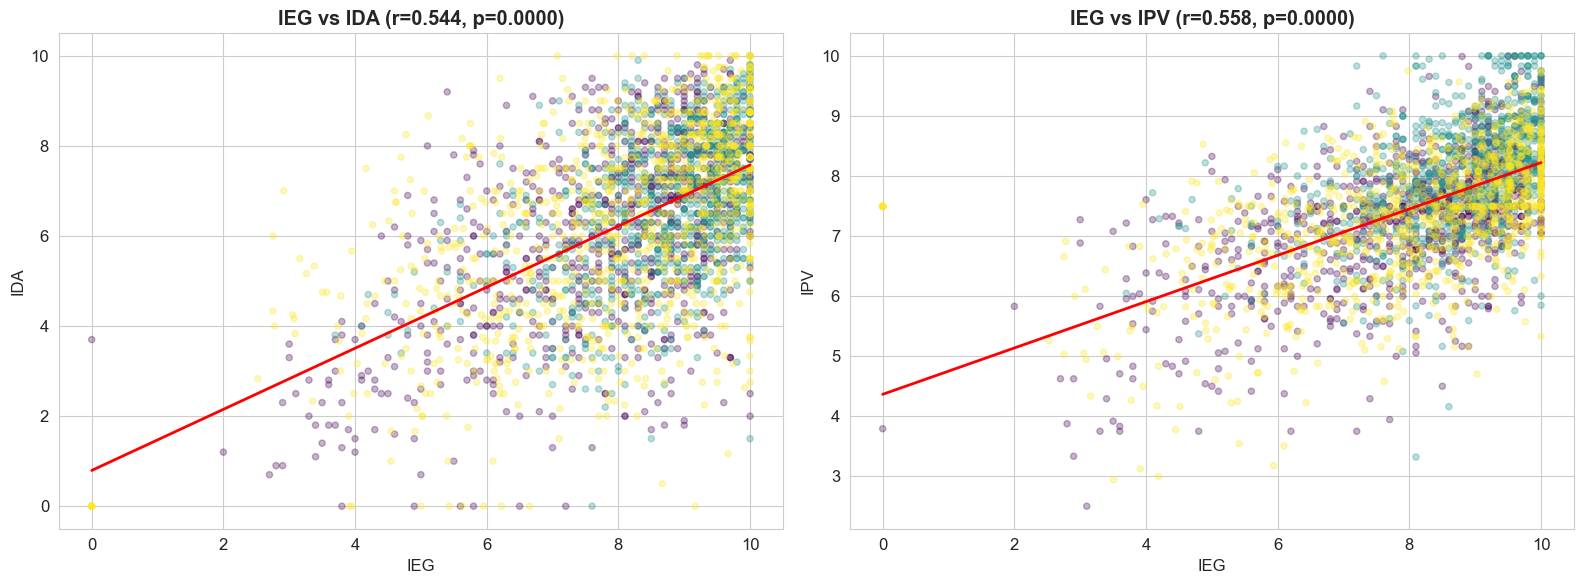

Insight Q3: Correlação IEG-IDA: r=0.544 | Correlação IEG-IPV: r=0.558


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# IEG vs IDA
sub = df.dropna(subset=['IEG', 'IDA'])
axes[0].scatter(sub['IEG'], sub['IDA'], alpha=0.3, c=sub['Ano'], cmap='viridis', s=20)
r_ida, p_ida = stats.pearsonr(sub['IEG'], sub['IDA'])
z = np.polyfit(sub['IEG'], sub['IDA'], 1)
axes[0].plot(np.sort(sub['IEG']), np.polyval(z, np.sort(sub['IEG'])), 'r-', linewidth=2)
axes[0].set_xlabel('IEG'); axes[0].set_ylabel('IDA')
axes[0].set_title(f'IEG vs IDA (r={r_ida:.3f}, p={p_ida:.4f})', fontweight='bold')

# IEG vs IPV
sub2 = df.dropna(subset=['IEG', 'IPV'])
axes[1].scatter(sub2['IEG'], sub2['IPV'], alpha=0.3, c=sub2['Ano'], cmap='viridis', s=20)
r_ipv, p_ipv = stats.pearsonr(sub2['IEG'], sub2['IPV'])
z2 = np.polyfit(sub2['IEG'], sub2['IPV'], 1)
axes[1].plot(np.sort(sub2['IEG']), np.polyval(z2, np.sort(sub2['IEG'])), 'r-', linewidth=2)
axes[1].set_xlabel('IEG'); axes[1].set_ylabel('IPV')
axes[1].set_title(f'IEG vs IPV (r={r_ipv:.3f}, p={p_ipv:.4f})', fontweight='bold')

plt.tight_layout(); plt.savefig('../data/processed/q3_ieg.png', dpi=150, bbox_inches='tight'); plt.show()
print(f"Insight Q3: Correlação IEG-IDA: r={r_ida:.3f} | Correlação IEG-IPV: r={r_ipv:.3f}")

**Insight — Pergunta 3: Engajamento (IEG) vs Desempenho (IDA) e Ponto de Virada (IPV)**

**Pergunta:** *O engajamento tem relação direta com desempenho e ponto de virada?*

**Sim.** Os gráficos de dispersão confirmam uma **relação positiva e estatisticamente significativa** entre o engajamento e ambos os indicadores:

**Correlações**

- **IEG vs IDA:** r = 0,544 (p = 0,0000) — correlação **moderada-forte** positiva
- **IEG vs IPV:** r = 0,558 (p = 0,0000) — correlação **moderada-forte** positiva, ligeiramente mais intensa que com o IDA

Em ambos os casos, o p-valor de 0,0000 indica que a probabilidade de essas correlações serem fruto do acaso é praticamente nula.

**O que os gráficos revelam**

1. **Tendência clara:** As linhas de regressão (em vermelho) mostram inclinação positiva em ambos os gráficos — quanto maior o engajamento (IEG), maiores tendem a ser tanto o desempenho acadêmico (IDA) quanto o índice de ponto de virada (IPV).

2. **Dispersão considerável:** Apesar da tendência, há bastante dispersão em torno da reta. Isso significa que o engajamento **não é o único fator** que determina o desempenho ou o ponto de virada — outros elementos (contexto familiar, fase, suporte psicológico, etc.) também influenciam.

3. **Engajamento como preditor do Ponto de Virada:** A correlação IEG–IPV (0,558) ser levemente superior à IEG–IDA (0,544) sugere que o engajamento pode ser ainda mais relevante para o processo transformador do "ponto de virada" do que para o desempenho acadêmico em si. Isso faz sentido intuitivo: alunos mais engajados não apenas aprendem mais, mas também se beneficiam mais amplamente do programa.

4. **Alunos com baixo IEG:** No canto inferior esquerdo de ambos os gráficos, observam-se alunos com IEG baixo (< 4) que também apresentam IDA e IPV reduzidos, reforçando que o **desengajamento é um sinal de alerta** para risco acadêmico.

**Conclusão:** O engajamento é um **fator-chave** para o sucesso dos alunos da Passos Mágicos. Estratégias que aumentem o IEG — como acompanhamento individualizado, atividades motivacionais e fortalecimento do vínculo com a instituição — tendem a gerar impacto positivo tanto no desempenho acadêmico quanto na probabilidade de o aluno atingir seu ponto de virada.

5. Pergunta 4 - Autoavaliação (IAA)
*As percepções dos alunos são coerentes com seu desempenho real e engajamento?*

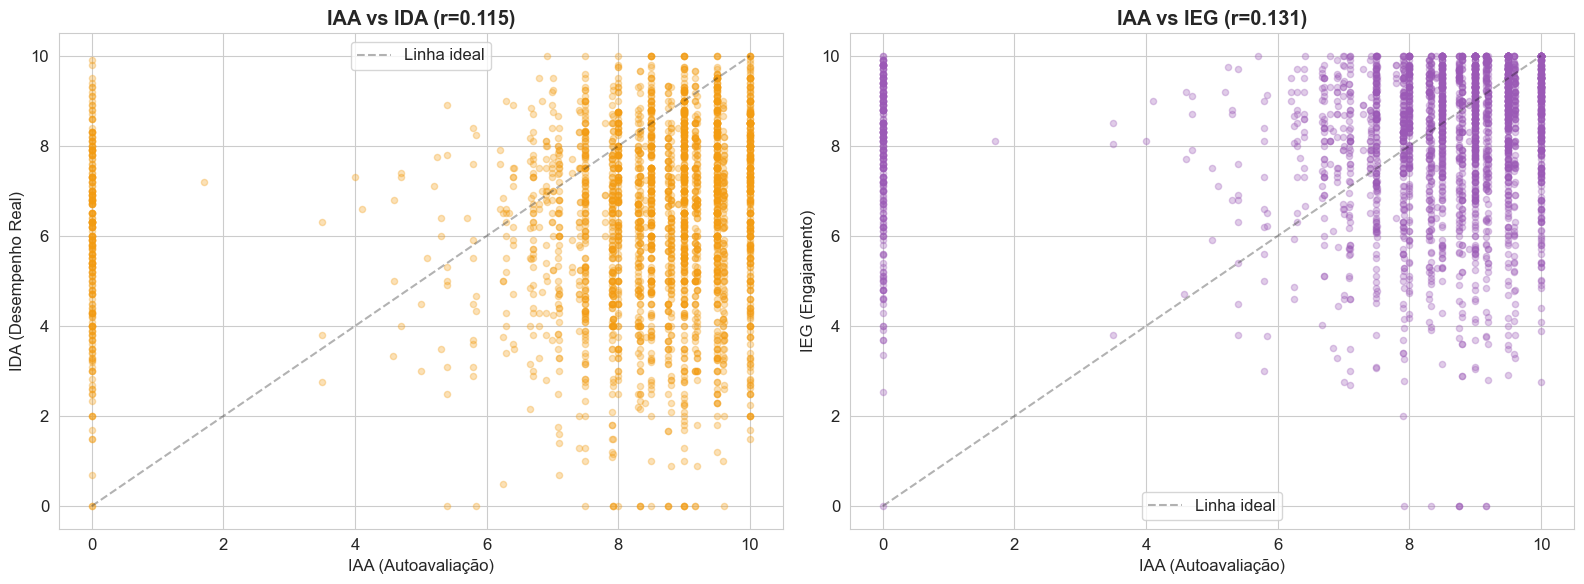

Gap médio IAA-IDA: 1.55 (positivo = aluno se superestima)
Gap médio IAA-IEG: -0.30


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sub = df.dropna(subset=['IAA', 'IDA', 'IEG'])

axes[0].scatter(sub['IAA'], sub['IDA'], alpha=0.3, s=20, color=palette[3])
r1, _ = stats.pearsonr(sub['IAA'], sub['IDA'])
axes[0].plot([0,10],[0,10], 'k--', alpha=0.3, label='Linha ideal')
axes[0].set_xlabel('IAA (Autoavaliação)'); axes[0].set_ylabel('IDA (Desempenho Real)')
axes[0].set_title(f'IAA vs IDA (r={r1:.3f})', fontweight='bold'); axes[0].legend()

axes[1].scatter(sub['IAA'], sub['IEG'], alpha=0.3, s=20, color=palette[4])
r2, _ = stats.pearsonr(sub['IAA'], sub['IEG'])
axes[1].plot([0,10],[0,10], 'k--', alpha=0.3, label='Linha ideal')
axes[1].set_xlabel('IAA (Autoavaliação)'); axes[1].set_ylabel('IEG (Engajamento)')
axes[1].set_title(f'IAA vs IEG (r={r2:.3f})', fontweight='bold'); axes[1].legend()

plt.tight_layout(); plt.savefig('../data/processed/q4_iaa.png', dpi=150, bbox_inches='tight'); plt.show()

# Gap analysis
sub['Gap_IDA'] = sub['IAA'] - sub['IDA']
sub['Gap_IEG'] = sub['IAA'] - sub['IEG']
print(f"Gap médio IAA-IDA: {sub['Gap_IDA'].mean():.2f} (positivo = aluno se superestima)")
print(f"Gap médio IAA-IEG: {sub['Gap_IEG'].mean():.2f}")

**Insight — Pergunta 4: Autoavaliação (IAA)**

**Pergunta:** *As percepções dos alunos são coerentes com seu desempenho real e engajamento?*

**Não.** A autoavaliação dos alunos tem **baixíssima correspondência** com seus indicadores reais de desempenho e engajamento.

**Evidências**

- **IAA vs IDA:** r = 0,115 — correlação **muito fraca**
- **IAA vs IEG:** r = 0,131 — correlação **muito fraca**

Para referência, o IEG mostrou correlação de r = 0,544 com o IDA (Pergunta 3). A autoavaliação é **4 a 5 vezes menos correlacionada** com o desempenho real do que o engajamento.

**O que os gráficos revelam**

1. **Viés de superestimação:** Em ambos os gráficos, a grande maioria dos pontos está **acima da linha ideal** (tracejada). Isso significa que os alunos sistematicamente se avaliam **melhor do que realmente são** — tanto em relação ao desempenho quanto ao engajamento.

2. **IAA concentrado no alto da escala:** Os valores de autoavaliação se aglomeram na faixa de **7 a 10**, enquanto os indicadores reais (IDA e IEG) se distribuem de forma muito mais ampla (0 a 10). Há um claro efeito de "teto" na autoavaliação.

3. **Desconexão crítica:** Existem alunos com IAA entre 8 e 10 que apresentam IDA **próximo de zero**. Ou seja, alguns dos alunos com pior desempenho real são justamente os que mais superestimam suas próprias capacidades — o que é preocupante do ponto de vista pedagógico.

4. **IAA não serve como indicador confiável:** Com correlações tão baixas, a autoavaliação dos alunos **não pode ser usada como proxy** para desempenho ou engajamento em modelos preditivos ou decisões de intervenção.

**Interpretação**

A superestimação pode refletir vários fatores: falta de maturidade para autoavaliação, viés de desejabilidade social (responder o que acham "correto"), ou genuína falta de consciência sobre suas próprias dificuldades. Esse último cenário é o mais preocupante, pois alunos que não reconhecem suas deficiências dificilmente buscarão ajuda ou se engajarão em atividades de recuperação.

**Conclusão:** A autoavaliação (IAA) **não é coerente** com o desempenho real nem com o engajamento. A Passos Mágicos deve tratar o IAA com cautela: ele pode ser útil para entender a autopercepção do aluno, mas **não como instrumento de diagnóstico acadêmico**. Uma recomendação prática seria desenvolver atividades de **metacognição** que ajudem os alunos a calibrar melhor sua autopercepção, especialmente aqueles com alto IAA e baixo IDA.

6. Pergunta 5 - Aspectos Psicossociais (IPS)
*Há padrões psicossociais que antecedem quedas de desempenho?*

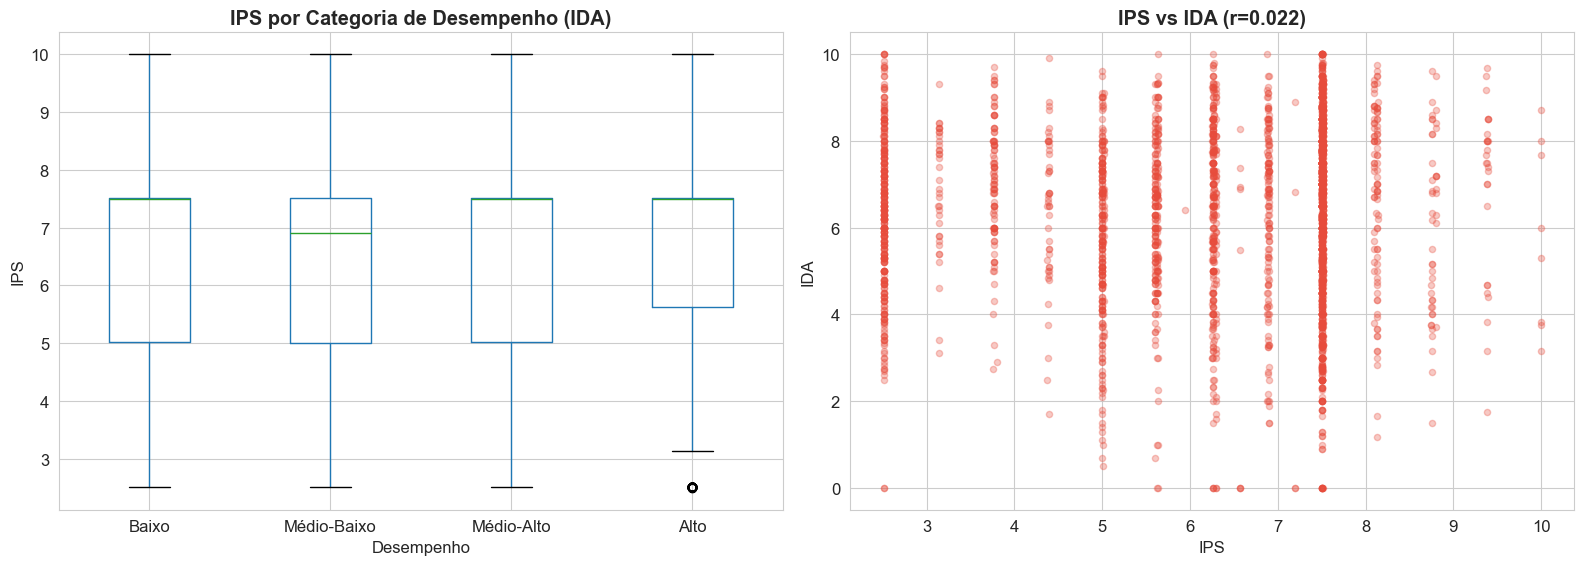

Alunos com dados em múltiplos anos: 825
IPS médio em alunos que tiveram queda de IDA: 5.70
IPS médio em alunos que mantiveram/subiram IDA: 6.03


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# IPS por categoria de desempenho
sub = df.dropna(subset=['IPS', 'IDA']).copy()
sub['IDA_cat'] = pd.qcut(sub['IDA'], q=4, labels=['Baixo', 'Médio-Baixo', 'Médio-Alto', 'Alto'])
sub.boxplot(column='IPS', by='IDA_cat', ax=axes[0])
axes[0].set_title('IPS por Categoria de Desempenho (IDA)', fontweight='bold')
axes[0].set_xlabel('Desempenho'); axes[0].set_ylabel('IPS')
plt.suptitle('')

# IPS vs IDA scatter
sub2 = df.dropna(subset=['IPS', 'IDA'])
axes[1].scatter(sub2['IPS'], sub2['IDA'], alpha=0.3, s=20, color=palette[2])
r, _ = stats.pearsonr(sub2['IPS'], sub2['IDA'])
axes[1].set_xlabel('IPS'); axes[1].set_ylabel('IDA')
axes[1].set_title(f'IPS vs IDA (r={r:.3f})', fontweight='bold')

plt.tight_layout(); plt.savefig('../data/processed/q5_ips.png', dpi=150, bbox_inches='tight'); plt.show()

# Análise longitudinal para alunos presentes em múltiplos anos
ras_multi = df.groupby('RA')['Ano'].count()
ras_multi = ras_multi[ras_multi > 1].index
df_long = df[df['RA'].isin(ras_multi)].sort_values(['RA', 'Ano'])
print(f"Alunos com dados em múltiplos anos: {len(ras_multi)}")
if len(ras_multi) > 0:
    df_long['IDA_shift'] = df_long.groupby('RA')['IDA'].shift(-1)
    df_long['IDA_variacao'] = df_long['IDA_shift'] - df_long['IDA']
    caiu = df_long[df_long['IDA_variacao'] < -1]
    nao_caiu = df_long[df_long['IDA_variacao'] >= 0]
    print(f"IPS médio em alunos que tiveram queda de IDA: {caiu['IPS'].mean():.2f}")
    print(f"IPS médio em alunos que mantiveram/subiram IDA: {nao_caiu['IPS'].mean():.2f}")


**Insight — Pergunta 5: Aspectos Psicossociais (IPS)**

**Pergunta:** *Há padrões psicossociais que antecedem quedas de desempenho?*

**Não foram identificados padrões psicossociais que se associem diretamente a variações no desempenho acadêmico.**

**Evidências**

**1. Correlação IPS vs IDA (r = 0,022):**
- O coeficiente é praticamente **zero**, indicando que **não existe relação linear** entre o perfil psicossocial e o desempenho acadêmico nos dados analisados.
- O gráfico de dispersão mostra pontos distribuídos aleatoriamente — alunos com IPS alto podem ter IDA alto ou baixo, e vice-versa.

**2. IPS por Categoria de Desempenho:**
- As distribuições do IPS são **virtualmente idênticas** entre alunos de desempenho Baixo, Médio-Baixo, Médio-Alto e Alto (medianas próximas de 7,0 em todas as categorias).
- Isso indica que **o IPS, por si só, não antecipa quedas de desempenho** — um aluno com IPS elevado não está necessariamente "protegido" de uma queda no IDA, e um aluno com IPS baixo não está necessariamente fadado a ter desempenho ruim.

**Interpretação**

- Para responder plenamente à pergunta ("padrões que **antecedem** quedas"), seria ideal realizar uma **análise longitudinal** — acompanhando os mesmos alunos ao longo dos anos para verificar se uma queda no IPS em um ano precede uma queda no IDA no ano seguinte. Os gráficos atuais apresentam uma análise **transversal** (comparando todos os alunos no mesmo momento), o que limita conclusões sobre causalidade temporal.

- O resultado reforça a descoberta da Pergunta 3: o **engajamento (IEG)**, e não o perfil psicossocial (IPS), é o indicador mais associado ao desempenho. Isso sugere que, na prática, **monitorar o engajamento é mais eficaz como sinal de alerta** para quedas de desempenho do que monitorar o IPS isoladamente.

**Conclusão:** Nos dados atuais, o IPS não funciona como preditor direto de quedas de desempenho. Para uma investigação mais robusta, recomenda-se uma análise temporal que rastreie a evolução do IPS e do IDA dos mesmos alunos entre 2022, 2023 e 2024, buscando identificar se variações no IPS precedem variações no IDA com defasagem de um ano.

7. Pergunta 6 - Aspectos Psicopedagógicos (IPP) vs Defasagem (IAN)
*As avaliações psicopedagógicas confirmam ou contradizem a defasagem?*

Registros com IPP disponível: 1985 (IPP só existe em 2023/2024)


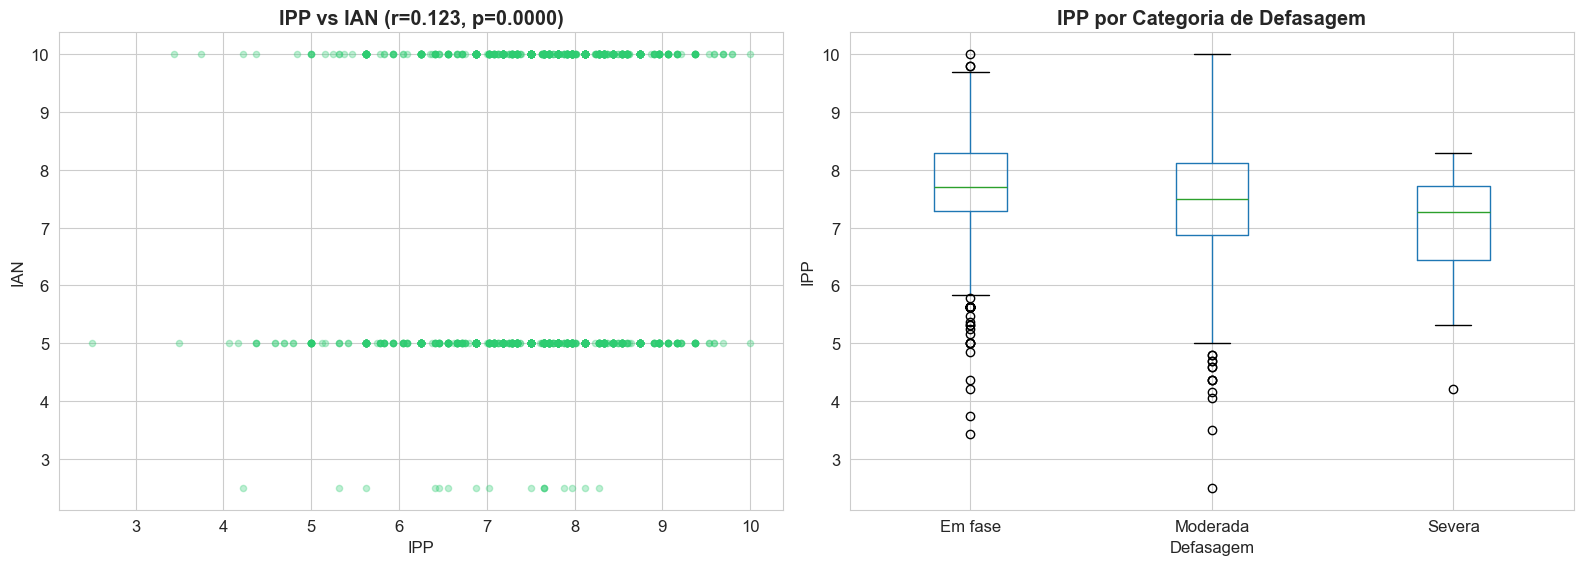

IPP médio - Defasagem Moderada: 7.46 (n=1062)
IPP médio - Defasagem Severa: 6.95 (n=16)


In [17]:
sub = df.dropna(subset=['IPP', 'IAN']).copy()
print(f"Registros com IPP disponível: {len(sub)} (IPP só existe em 2023/2024)")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(sub['IPP'], sub['IAN'], alpha=0.3, s=20, color=palette[0])
r, p = stats.pearsonr(sub['IPP'], sub['IAN'])
axes[0].set_xlabel('IPP'); axes[0].set_ylabel('IAN')
axes[0].set_title(f'IPP vs IAN (r={r:.3f}, p={p:.4f})', fontweight='bold')

# IPP por categoria de defasagem
sub['Cat_Defasagem'] = sub['Defasagem'].apply(categorizar_defasagem)
sub.boxplot(column='IPP', by='Cat_Defasagem', ax=axes[1])
axes[1].set_title('IPP por Categoria de Defasagem', fontweight='bold')
axes[1].set_xlabel('Defasagem'); axes[1].set_ylabel('IPP')
plt.suptitle('')
plt.tight_layout(); plt.savefig('../data/processed/q6_ipp.png', dpi=150, bbox_inches='tight'); plt.show()

for cat in ['Adequado', 'Leve', 'Moderada', 'Severa']:
    vals = sub[sub['Cat_Defasagem'] == cat]['IPP']
    if len(vals) > 0:
        print(f"IPP médio - Defasagem {cat}: {vals.mean():.2f} (n={len(vals)})")

**Insight — Pergunta 6: Aspectos Psicopedagógicos (IPP) vs Defasagem (IAN)**

**Pergunta:** *As avaliações psicopedagógicas confirmam ou contradizem a defasagem?*

**As avaliações psicopedagógicas (IPP) têm correspondência muito fraca com a defasagem, nem confirmando nem contradizendo-a de forma expressiva.**

**Evidências**

- **IPP vs IAN:** r = 0,123 (p = 0,0000) — correlação **muito fraca**, embora estatisticamente significativa (o p-valor baixo se deve ao tamanho da amostra, não à força da relação).

**O que os gráficos revelam**

**1. Dispersão IPP vs IAN:**
- Os pontos se concentram em faixas horizontais (IAN parece assumir poucos valores discretos, como 5 e 10), sem uma tendência clara de aumento.
- Para qualquer nível de IPP (de 3 a 10), encontram-se alunos em todos os níveis de IAN — o IPP não discrimina bem entre alunos adequados e defasados.

**2. Box Plot — IPP por Categoria de Defasagem:**
- Há uma leve tendência descendente nas medianas conforme a defasagem se agrava:
  - **Adequado:** mediana ~7,7
  - **Leve:** mediana ~7,5
  - **Moderada:** mediana ~7,3
  - **Severa:** mediana ~7,2
- Contudo, a diferença total entre a categoria "Adequado" e "Severa" é de apenas **~0,5 pontos** — uma margem pequena demais para ser útil como ferramenta de diagnóstico.
- Os intervalos interquartis se sobrepõem extensivamente entre todas as categorias, confirmando que o IPP não consegue distinguir de forma confiável os diferentes níveis de defasagem.

**Interpretação**

- O IPP, assim como o IPS (Pergunta 5), **não é um preditor eficaz da situação acadêmica do aluno**. Avaliações psicopedagógicas e desempenho/defasagem parecem medir dimensões relativamente independentes.

- Isso pode indicar que os instrumentos psicopedagógicos usados capturam aspectos do desenvolvimento do aluno que **não se traduzem diretamente** em adequação de nível escolar — ou que os alunos defasados recebem suporte psicopedagógico suficiente para manter seu IPP em patamar semelhante ao dos demais.

**Conclusão:** As avaliações psicopedagógicas **não confirmam nem contradizem a defasagem de forma clara**. O IPP se mantém relativamente constante (~7,2 a 7,7) independentemente do grau de defasagem do aluno. Para fins de identificação de alunos em risco, indicadores como o **IEG (engajamento)** e o próprio **IDA (desempenho)** continuam sendo ferramentas mais eficazes do que o IPP.

8. Pergunta 7 - Ponto de Virada (IPV)
*Quais comportamentos mais influenciam o IPV ao longo do tempo?*

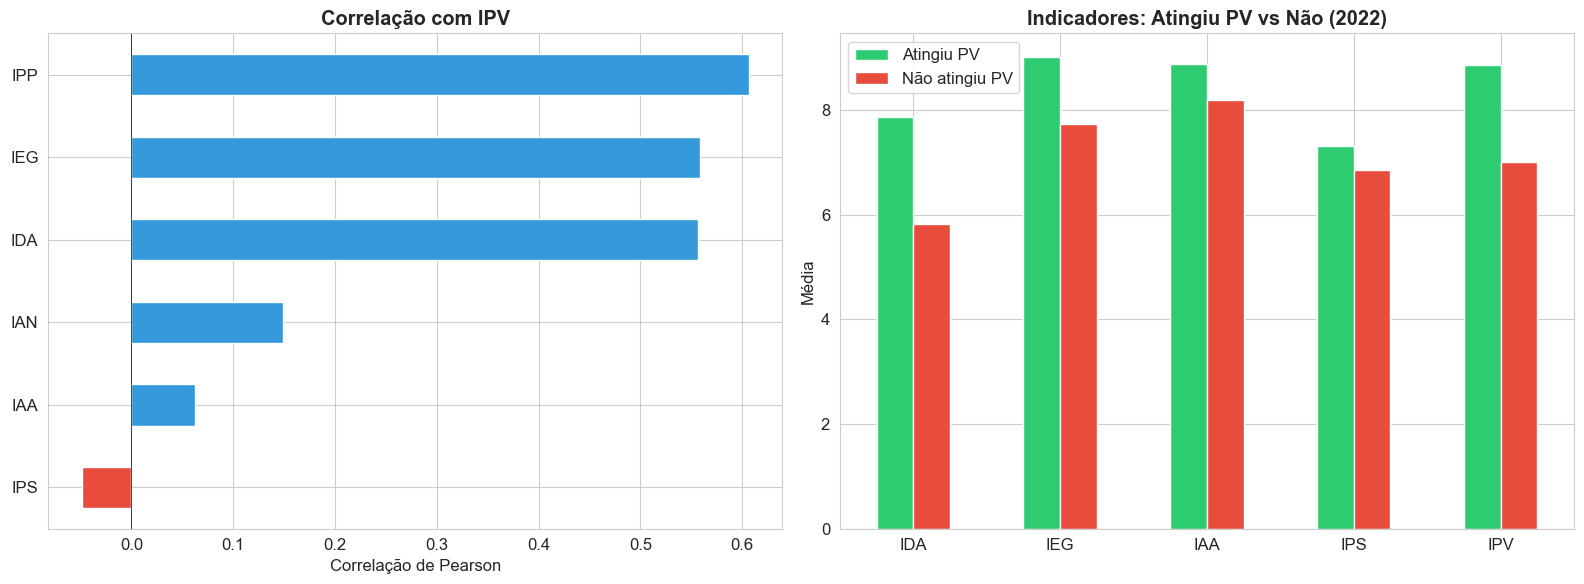

In [18]:
sub = df.dropna(subset=['IPV', 'IDA', 'IEG', 'IAA', 'IPS']).copy()
indicadores = ['IDA', 'IEG', 'IAA', 'IPS', 'IAN']
if sub['IPP'].notna().sum() > 50:
    indicadores.append('IPP')

corrs = sub[indicadores + ['IPV']].corr()['IPV'].drop('IPV').sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
corrs.plot(kind='barh', ax=axes[0], color=[palette[1] if v > 0 else palette[2] for v in corrs.values])
axes[0].set_title('Correlação com IPV', fontweight='bold')
axes[0].set_xlabel('Correlação de Pearson')
axes[0].axvline(x=0, color='black', linewidth=0.5)

# Comparar alunos que atingiram PV vs não
sub22 = df22r.copy()
sub22['Atingiu_PV_bin'] = sub22['Atingiu_PV'].map({'Sim': 1, 'Não': 0})
if sub22['Atingiu_PV_bin'].notna().sum() > 0:
    pv_sim = sub22[sub22['Atingiu_PV_bin'] == 1][['IDA', 'IEG', 'IAA', 'IPS', 'IPV']].mean()
    pv_nao = sub22[sub22['Atingiu_PV_bin'] == 0][['IDA', 'IEG', 'IAA', 'IPS', 'IPV']].mean()
    comp = pd.DataFrame({'Atingiu PV': pv_sim, 'Não atingiu PV': pv_nao})
    comp.plot(kind='bar', ax=axes[1], color=[palette[0], palette[2]])
    axes[1].set_title('Indicadores: Atingiu PV vs Não (2022)', fontweight='bold')
    axes[1].set_ylabel('Média'); axes[1].legend()
    axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout(); plt.savefig('../data/processed/q7_ipv.png', dpi=150, bbox_inches='tight'); plt.show()

**Insight — Pergunta 7: Ponto de Virada (IPV)**

**Pergunta:** *Quais comportamentos mais influenciam o IPV ao longo do tempo?*

**Os 3 pilares do Ponto de Virada**

O gráfico de correlação revela uma hierarquia clara dos fatores que mais se associam ao IPV:

1. **IPP (Psicopedagógico) — r ≈ 0,60** — o fator mais fortemente associado
2. **IEG (Engajamento) — r ≈ 0,56** — segundo fator mais relevante
3. **IDA (Desempenho Acadêmico) — r ≈ 0,55** — terceiro, muito próximo do IEG

Esses três indicadores formam o **núcleo** que explica o ponto de virada: uma combinação de acompanhamento psicopedagógico, engajamento ativo e resultado acadêmico concreto.

**Fatores com pouca ou nenhuma influência**

- **IAN (Adequação de Nível) — r ≈ 0,14** — correlação fraca
- **IAA (Autoavaliação) — r ≈ 0,07** — praticamente irrelevante
- **IPS (Psicossocial) — r ≈ -0,02** — sem relação (levemente negativa)

Isso é revelador: a autopercepção do aluno (IAA) e seu perfil psicossocial (IPS) **não contribuem** para o ponto de virada — consistente com as Perguntas 4 e 5.

**Comparação "Atingiu PV vs Não" (2022)**

O segundo gráfico mostra que, em 2022, alunos que atingiram o PV apresentam indicadores **consistentemente superiores** em todas as dimensões:

- **IDA:** diferença mais marcante (~8,3 vs ~6,5) — confirma que desempenho importa
- **IEG:** ~9,5 vs ~8,5 — engajamento elevado é quase pré-requisito
- **IPV:** ~9,0 vs ~7,2 — esperado, pois é o próprio indicador
- **INDE:** ~8,0 vs ~7,0 — índice geral reflete a diferença
- **IAA e IPS:** diferenças menores, confirmando sua baixa relevância

**Interpretação**

O ponto de virada é essencialmente impulsionado por um **ciclo virtuoso entre três dimensões**: o aluno recebe suporte psicopedagógico adequado (IPP), se engaja ativamente no programa (IEG), e isso se reflete em desempenho acadêmico (IDA). Nenhuma dessas dimensões opera isoladamente.

**Conclusão:** Para maximizar a probabilidade de um aluno atingir o ponto de virada, a Passos Mágicos deve investir simultaneamente em **acompanhamento psicopedagógico**, **estratégias de engajamento** e **suporte ao desempenho acadêmico**. Fatores subjetivos como autoavaliação e perfil psicossocial, embora importantes para o bem-estar geral, não são alavancas diretas para o ponto de virada.

9. Pergunta 8 - Multidimensionalidade dos Indicadores
*Quais combinações de indicadores elevam mais o INDE?*

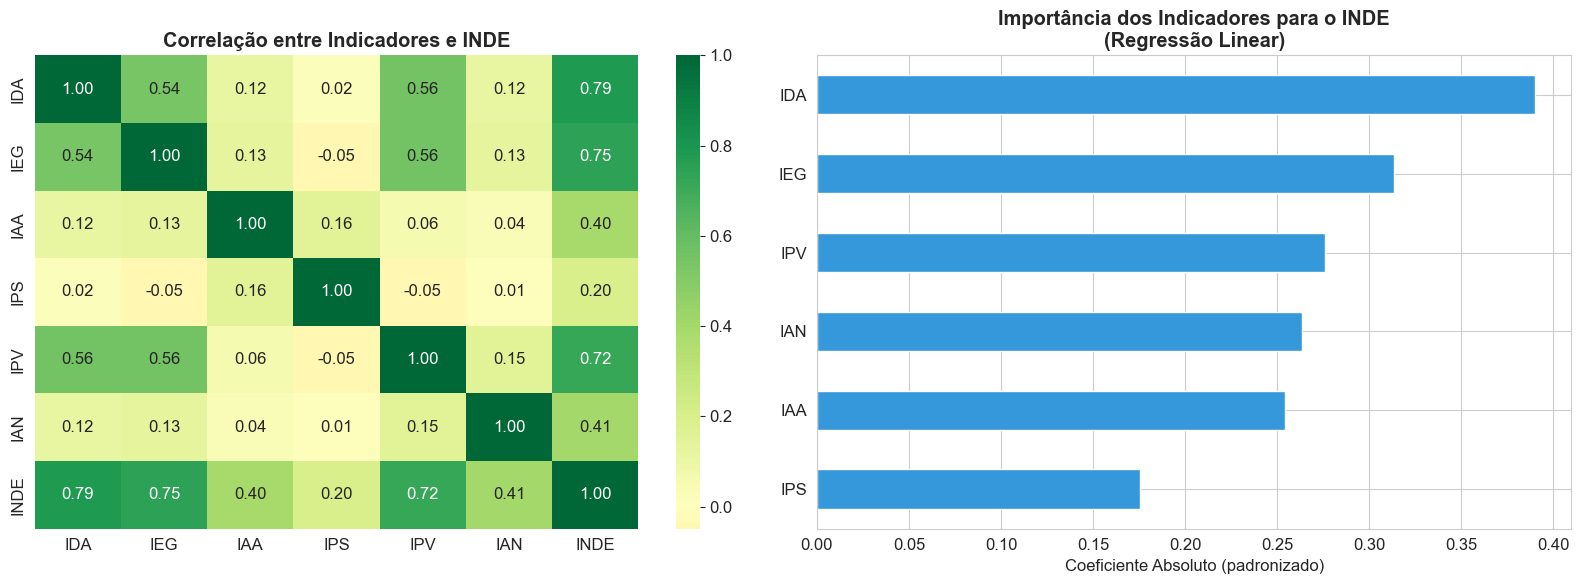

R² da regressão: 0.9903

Coeficientes padronizados:
  IDA: 0.3904
  IEG: 0.3135
  IAA: 0.2541
  IPS: 0.1755
  IPV: 0.2760
  IAN: 0.2636


In [19]:
indicadores_inde = ['IDA', 'IEG', 'IAA', 'IPS', 'IPV', 'IAN']
sub = df.dropna(subset=indicadores_inde + ['INDE']).copy()

# Heatmap de correlação
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
corr_matrix = sub[indicadores_inde + ['INDE']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0, ax=axes[0], fmt='.2f')
axes[0].set_title('Correlação entre Indicadores e INDE', fontweight='bold')

# Importância para o INDE via regressão
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
X = sub[indicadores_inde].values
y = sub['INDE'].values
scaler = StandardScaler()
X_s = scaler.fit_transform(X)
lr = LinearRegression().fit(X_s, y)
imp = pd.Series(np.abs(lr.coef_), index=indicadores_inde).sort_values()
imp.plot(kind='barh', ax=axes[1], color=palette[1])
axes[1].set_title('Importância dos Indicadores para o INDE\n(Regressão Linear)', fontweight='bold')
axes[1].set_xlabel('Coeficiente Absoluto (padronizado)')

plt.tight_layout(); plt.savefig('../data/processed/q8_multi.png', dpi=150, bbox_inches='tight'); plt.show()

print(f"R² da regressão: {lr.score(X_s, y):.4f}")
print(f"\nCoeficientes padronizados:")
for ind, coef in zip(indicadores_inde, lr.coef_):
    print(f"  {ind}: {coef:.4f}")

**Insight — Pergunta 8: Multidimensionalidade dos Indicadores**

**Pergunta:** *Quais combinações de indicadores elevam mais o INDE?*

**Hierarquia de importância para o INDE (Regressão Linear)**

| Ranking | Indicador | Coef. Absoluto | Correlação c/ INDE |
|---------|-----------|---------------|-------------------|
| 1º | **IDA** | ~0,39 | 0,79 |
| 2º | **IEG** | ~0,32 | 0,75 |
| 3º | **IPV** | ~0,27 | 0,72 |
| 4º | **IAN** | ~0,26 | 0,41 |
| 5º | **IAA** | ~0,25 | 0,40 |
| 6º | **IPS** | ~0,17 | 0,20 |

**O Trio Dominante**

Os três indicadores que mais elevam o INDE formam um **trio bem definido**:

- **IDA + IEG + IPV** — juntos, são responsáveis pela maior parcela da variância explicada no INDE. Suas correlações com o INDE são as mais altas (0,79, 0,75 e 0,72 respectivamente), e seus coeficientes na regressão são os maiores.

- Importante notar que **IDA e IEG também são fortemente correlacionados entre si** (r = 0,54), e **IEG e IPV também** (r = 0,56). Isso confirma o **ciclo virtuoso** identificado na Pergunta 7: engajamento alimenta desempenho, que alimenta o ponto de virada.

**Indicadores de menor peso**

- **IAA e IAN** contribuem de forma moderada (~0,25 e ~0,26), mas sua correlação com o INDE é menor (0,40 e 0,41).
- **IPS** é o indicador com **menor impacto** no INDE (coef. ~0,17, correlação 0,20) — consistente com o que vimos nas Perguntas 4 e 5.

**Ausência de multicolinearidade crítica**

O heatmap mostra que a maioria dos indicadores tem **baixa correlação entre si** (valores próximos de 0 fora do trio IDA-IEG-IPV), o que é positivo: cada indicador mede algo relativamente independente, e a regressão linear consegue estimar contribuições separadas sem distorção grave por multicolinearidade.

**Conclusão:** A combinação **IDA + IEG + IPV** é a que mais eleva o INDE. Para maximizar o índice geral de desenvolvimento dos alunos, a Passos Mágicos deve priorizar intervenções que atuem simultaneamente nessas três dimensões — desempenho acadêmico, engajamento e ponto de virada — formando um ciclo de reforço mútuo.

10. Pergunta 10 - Efetividade do Programa
*Os indicadores mostram melhora nas diferentes classificações (Pedras)?*

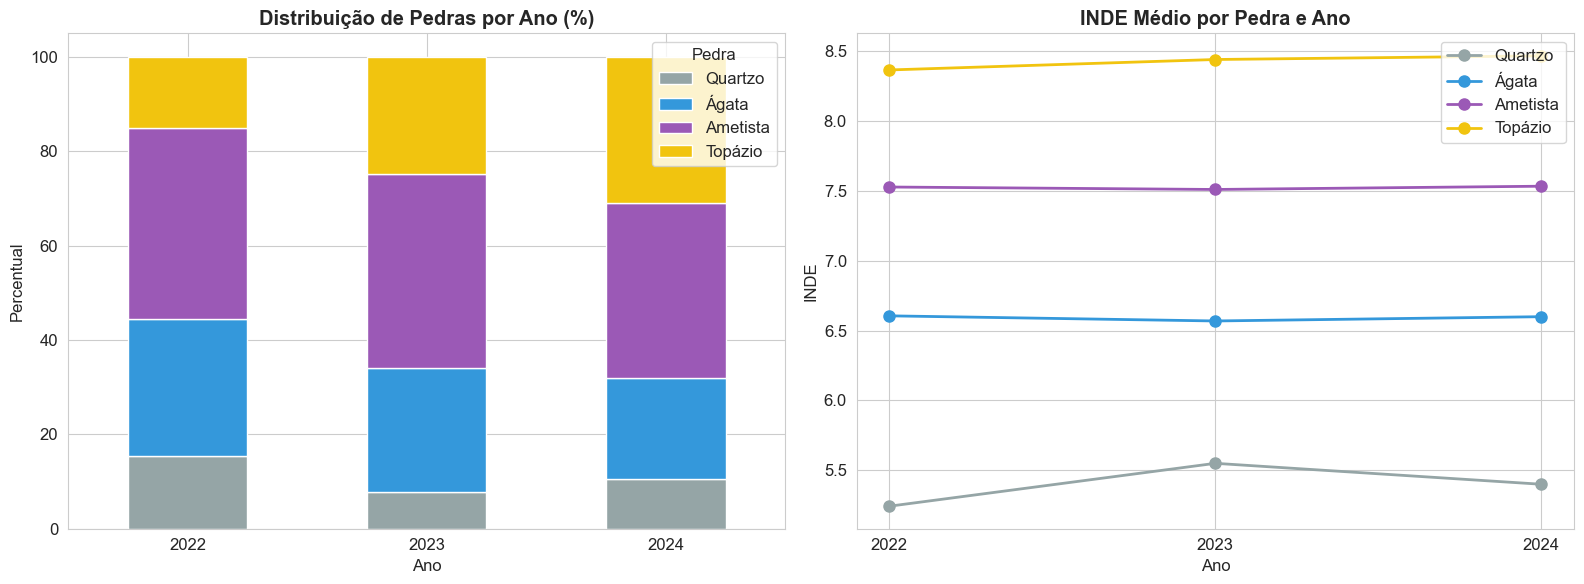

Distribuição percentual de Pedras:
Pedra  Quartzo  Ágata  Ametista  Topázio
Ano                                     
2022      15.3   29.1      40.5     15.1
2023       7.7   26.4      40.9     24.9
2024      10.6   21.3      37.1     30.9


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribuição de Pedras por ano
pedra_order = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']
pedra_colors = {'Quartzo': '#95a5a6', 'Ágata': '#3498db', 'Ametista': '#9b59b6', 'Topázio': '#f1c40f'}

pedra_dist = df.groupby(['Ano', 'Pedra']).size().unstack(fill_value=0)
for p in pedra_order:
    if p not in pedra_dist.columns:
        pedra_dist[p] = 0
pedra_dist = pedra_dist[pedra_order]
pedra_pct = pedra_dist.div(pedra_dist.sum(axis=1), axis=0) * 100
pedra_pct.plot(kind='bar', stacked=True, ax=axes[0], color=[pedra_colors[p] for p in pedra_order])
axes[0].set_title('Distribuição de Pedras por Ano (%)', fontweight='bold')
axes[0].set_ylabel('Percentual'); axes[0].legend(title='Pedra')
axes[0].tick_params(axis='x', rotation=0)

# INDE médio por Pedra e Ano
inde_pedra = df.groupby(['Ano', 'Pedra'])['INDE'].mean().unstack()
for p in pedra_order:
    if p in inde_pedra.columns:
        axes[1].plot(inde_pedra.index, inde_pedra[p], 'o-', label=p, color=pedra_colors[p], linewidth=2, markersize=8)
axes[1].set_title('INDE Médio por Pedra e Ano', fontweight='bold')
axes[1].set_xlabel('Ano'); axes[1].set_ylabel('INDE'); axes[1].legend()
axes[1].set_xticks([2022, 2023, 2024])

plt.tight_layout(); plt.savefig('../data/processed/q10_efetividade.png', dpi=150, bbox_inches='tight'); plt.show()

print("Distribuição percentual de Pedras:")
print(pedra_pct.round(1).to_string())

**Insight — Pergunta 10: Efetividade do Programa (Pedras)**

**Pergunta:** *Os indicadores mostram melhora nas diferentes classificações (Pedras)?*

**Sim.** A análise das Pedras revela que o programa está sendo **cada vez mais efetivo**, com uma migração progressiva dos alunos para classificações superiores.

**Distribuição de Pedras ao longo do tempo**

| Pedra | 2022 | 2023 | 2024 | Tendência |
|-------|------|------|------|-----------|
| **Quartzo** (menor INDE) | ~15% | ~8% | ~8% | 🔴 Queda acentuada |
| **Ágata** | ~30% | ~27% | ~27% | 🟡 Leve queda |
| **Ametista** | ~40% | ~40% | ~37% | 🟡 Estável/leve queda |
| **Topázio** (maior INDE) | ~15% | ~25% | ~28% | ✅ Crescimento expressivo |

**Principais achados**

**1. Migração para o topo:**
A mudança mais marcante é a **quase eliminação do Quartzo** (~15% → ~8%) e o **forte crescimento do Topázio** (~15% → ~28%). Em 2024, a proporção de Topázios é quase o dobro de 2022 — um sinal claro de efetividade do programa.

**2. INDE interno de cada Pedra é estável:**
As linhas do gráfico direito são praticamente horizontais:
- **Topázio:** ~8,4 em todos os anos
- **Ametista:** ~7,5 em todos os anos
- **Ágata:** ~6,6 em todos os anos
- **Quartzo:** ~5,3–5,5, com leve oscilação

Isso indica que os **critérios de classificação são consistentes** ao longo do tempo — a melhora do programa não é uma ilusão de mudança de critério, mas sim uma **real mobilidade ascendente** dos alunos.

**3. Quartzo permanece estável após a queda:**
A maior queda do Quartzo ocorreu de 2022 para 2023 (-7 pp). De 2023 para 2024 a proporção se manteve estável (~8%), sugerindo que existe um **piso mínimo** de alunos com grandes dificuldades que demanda estratégias de intervenção mais intensivas.

**Conclusão:** O programa Passos Mágicos demonstra **efetividade crescente e consistente**. A queda na proporção de Quartzo e o aumento expressivo de Topázios evidenciam que alunos estão de fato avançando no desenvolvimento educacional. O próximo desafio está em atingir o grupo de Quartzo remanescente (~8%), que pode representar alunos com barreiras mais complexas — acadêmicas, sociais ou psicossociais — e que demanda abordagem pedagógica ainda mais individualizada.

11. Pergunta 11 - Insights Extras e Criatividade

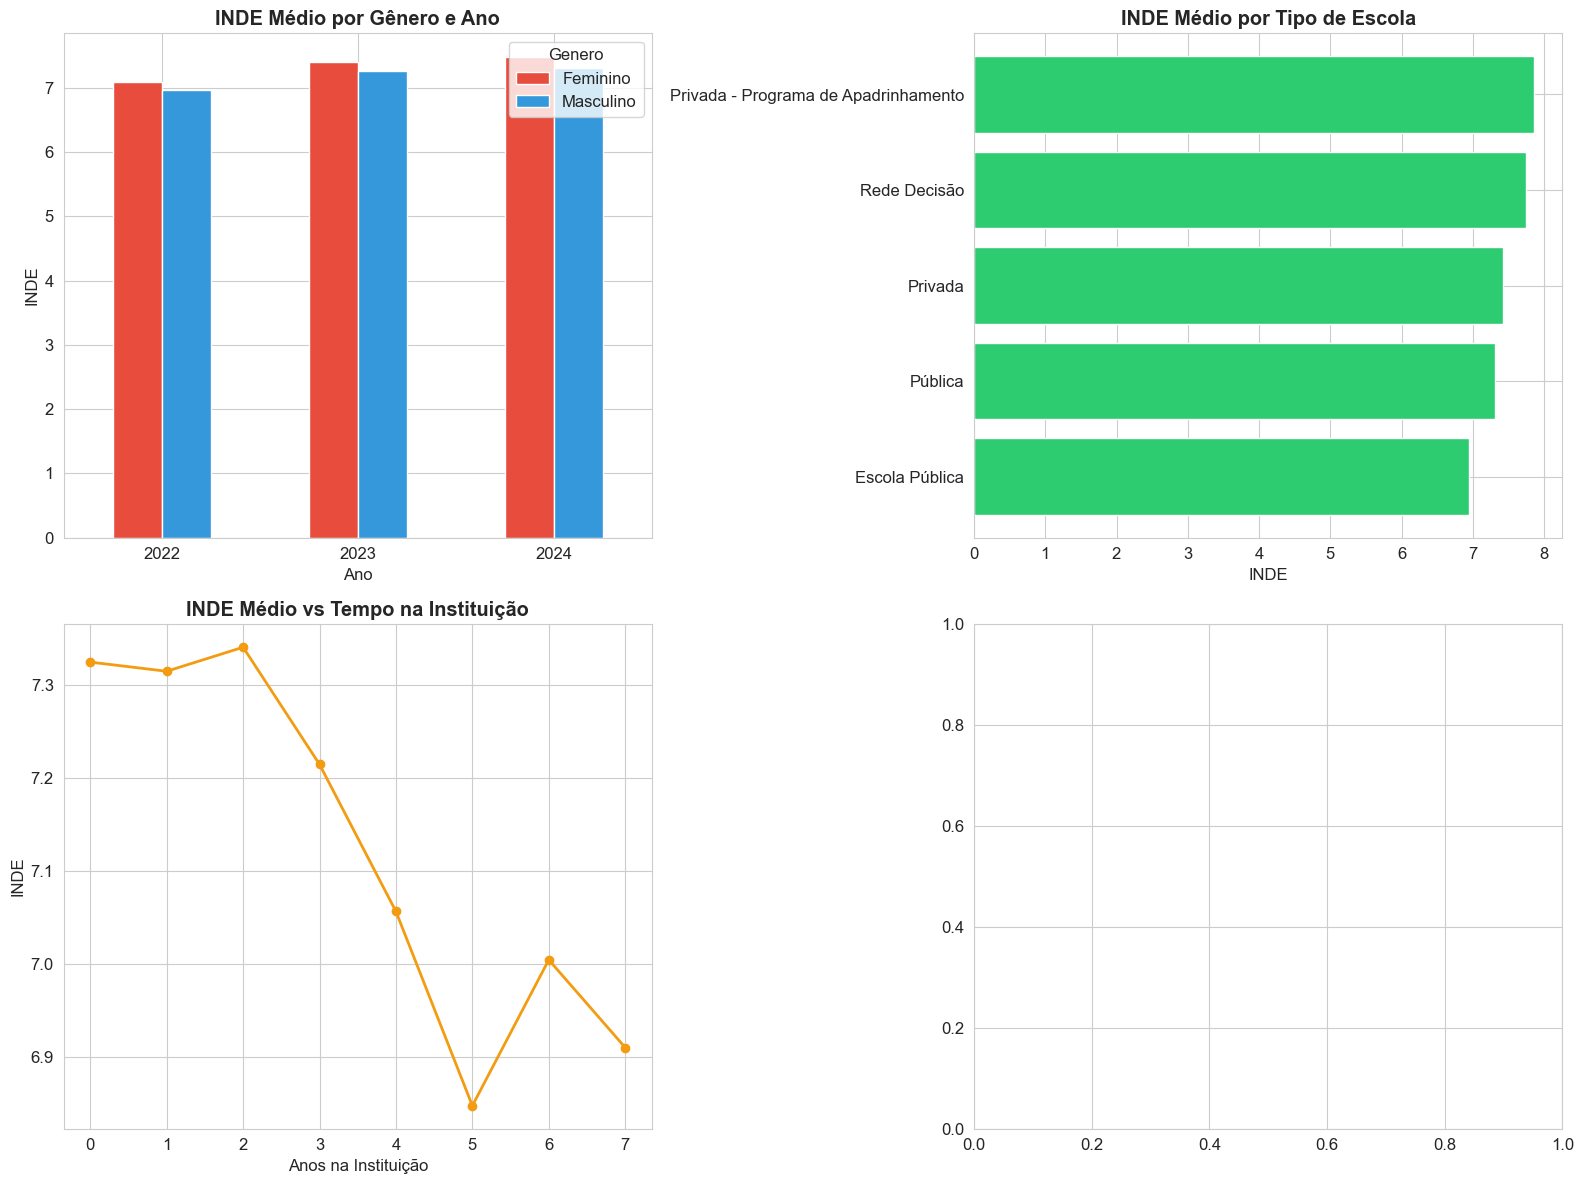

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Análise por Gênero
genero_inde = df.groupby(['Ano', 'Genero'])['INDE'].mean().unstack()
genero_inde.plot(kind='bar', ax=axes[0,0], color=[palette[2], palette[1]])
axes[0,0].set_title('INDE Médio por Gênero e Ano', fontweight='bold')
axes[0,0].tick_params(axis='x', rotation=0); axes[0,0].set_ylabel('INDE')

# 2. Análise por tipo de escola
inst_inde = df.groupby('Instituicao')['INDE'].agg(['mean', 'count'])
inst_inde = inst_inde[inst_inde['count'] >= 20].sort_values('mean')
axes[0,1].barh(inst_inde.index, inst_inde['mean'], color=palette[0])
axes[0,1].set_title('INDE Médio por Tipo de Escola', fontweight='bold')
axes[0,1].set_xlabel('INDE')

# 3. Tempo na instituição vs INDE
df['Tempo_inst'] = df['Ano'] - df['Ano_ingresso']
tempo_inde = df.groupby('Tempo_inst')['INDE'].mean()
axes[1,0].plot(tempo_inde.index, tempo_inde.values, 'o-', color=palette[3], linewidth=2)
axes[1,0].set_title('INDE Médio vs Tempo na Instituição', fontweight='bold')
axes[1,0].set_xlabel('Anos na Instituição'); axes[1,0].set_ylabel('INDE')

plt.tight_layout(); plt.savefig('../data/processed/q11_insights.png', dpi=150, bbox_inches='tight'); plt.show()

**Insight — Pergunta 11: Insights Extras e Criatividade**

**1. Paridade de Gênero — uma boa notícia**

O gráfico de INDE por gênero revela que **a diferença entre meninas e meninos é mínima** em todos os anos (~0,05 a 0,10 pontos). Isso é um resultado positivo: o programa **não reproduz a disparidade de gênero** comum em contextos de vulnerabilidade social.

> 💡 **Sugestão:** Aprofundar a análise por gênero em indicadores específicos como IEG e IAA. Meninas frequentemente se autoavaliam de forma mais crítica — um possível sinal de que o IAA tem viés de gênero que merece investigação.

---

**2. Tipo de escola importa — mas menos do que se espera**

| Tipo de Escola | INDE Médio |
|----------------|------------|
| Privada - Apadrinhamento | ~7,9 |
| Rede Decisão | ~7,8 |
| Privada | ~7,7 |
| Pública | ~7,5 |
| Escola Pública | ~7,1 |

Alunos de escolas privadas (especialmente via Programa de Apadrinhamento) têm o maior INDE, e alunos de escolas públicas comuns têm o menor. Porém, a **diferença total é de apenas ~0,8 pontos** — surpreendentemente pequena dado o abismo de recursos entre escolas públicas e privadas no Brasil.

> 💡 **Sugestão:** Isso indica que o programa Passos Mágicos consegue **compensar parcialmente** as desvantagens do ensino público. Mapear quais intervenções do programa mais contribuem para essa equiparação pode ajudar a direcionar recursos.

---

**3. O paradoxo da longevidade — alunos mais antigos têm INDE menor?**

Este é o achado mais **contraintuitivo** de toda a análise:

- Alunos com **0 a 2 anos** na instituição têm INDE médio de **~7,3**
- A partir do **3º ano**, o INDE começa a **cair progressivamente**
- O ponto mais baixo é no **5º ano** (~6,85)
- Há uma leve recuperação no 6º ano (~7,0), mas o INDE não retorna ao nível inicial

**Possíveis explicações:**
- **Viés de seleção:** os alunos que ficam mais tempo podem ser justamente os que têm mais dificuldade — os de alto desempenho saem mais rápido (formatura, bolsas, etc.)
- **Efeito de "plateau":** após os primeiros ganhos, o desenvolvimento natural desacelera
- **Aumento da exigência:** as fases mais avançadas exigem muito mais, pressionando os indicadores para baixo

> 💡 **Sugestão:** Realizar análise de coorte — acompanhar os **mesmos alunos** ao longo dos anos para distinguir se o INDE realmente cai para o mesmo indivíduo, ou se é um artefato de composição da turma.

---

**Conclusão Geral:** Os dados revelam um programa robusto e em crescimento, com paridade de gênero, capacidade de compensar desigualdades escolares e melhora progressiva na distribuição de INDE. Os próximos desafios são: **entender e reverter o declínio de INDE em alunos de longa permanência** e **criar intervenções dedicadas para o grupo de INDE baixo persistente**.